# Bimaterial characterization — 10k-sample sweep

This notebook scales `configs/bimat_characterization_campaign.yaml` from 24 demo samples to a **10 240-sample dataset** suitable for ML training, then runs it under MPI.

Each microstructure (a thresholded Gaussian random field, TPU vs PLA, ~100× modulus contrast) is exercised through 8 standard characterization modes:

| # | Mode | LC type | params |
|---|------|---------|--------|
| 1 | uniaxial tension x      | `uniaxial` | `disp_mag=+0.01, direction=x` |
| 2 | uniaxial compression x  | `uniaxial` | `disp_mag=-0.01, direction=x` |
| 3 | uniaxial tension y      | `uniaxial` | `disp_mag=+0.01, direction=y` |
| 4 | uniaxial compression y  | `uniaxial` | `disp_mag=-0.01, direction=y` |
| 5 | simple shear x          | `shear`    | `disp_mag=+0.01, direction=x` |
| 6 | simple shear y          | `shear`    | `disp_mag=+0.01, direction=y` |
| 7 | equi-biaxial tension    | `biaxial`  | `disp_x=+0.01, disp_y=+0.01` |
| 8 | equi-biaxial compression| `biaxial`  | `disp_x=-0.01, disp_y=-0.01` |

Workflow: **(1)** build a YAML over 10k samples programmatically → **(2)** sanity-check with a dry-run + a 2-sample slice → **(3)** launch the full sweep under `mpirun` → **(4)** inspect / visualize the result.

Units: MPa–mm–ms (E in MPa, density in Mg/mm³).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import yaml

from fem_sim import build_dataset, CampaignConfig

plt.rcParams["figure.dpi"] = 100

REPO = Path("..").resolve()
CONFIG_PATH = REPO / "configs" / "bimat_characterization_10k.yaml"
OUTPUT_DIR = REPO / "outputs" / "datasets" / "bimat_characterization_10k"
REPO, CONFIG_PATH

(PosixPath('/Users/jt35560/WorkSpace/fem-sim'),
 PosixPath('/Users/jt35560/WorkSpace/fem-sim/configs/bimat_characterization_10k.yaml'))

## 1. Constituent materials reference (before simulation)

The campaign mixes two phases at ~100× modulus contrast. Their plane-stress linear-elastic responses can be written in closed form, so we plot them *before* running anything as a sanity check on what the homogenized curves in §8–§9 should bracket.

| material | E (MPa) | ν    | ρ (Mg/mm³) | role        |
|----------|--------:|-----:|-----------:|-------------|
| TPU      | 30.0    | 0.48 | 1.2e-9     | soft phase  |
| PLA      | 3500.0  | 0.36 | 1.24e-9    | stiff phase |

Plane-stress closed-form responses used below:

* **uniaxial:**     σ = E · ε
* **simple shear:** τ = G · γ,  with  G = E / (2(1+ν))
* **equi-biaxial:** σ_xx = E/(1−ν) · ε   (when ε_xx = ε_yy)

The slope of each line is the *intrinsic modulus* of the pure phase. Anywhere the homogenized curve from §8 lands between the TPU and PLA lines is a Hashin–Shtrikman-style mixture; anywhere outside would be a bug.

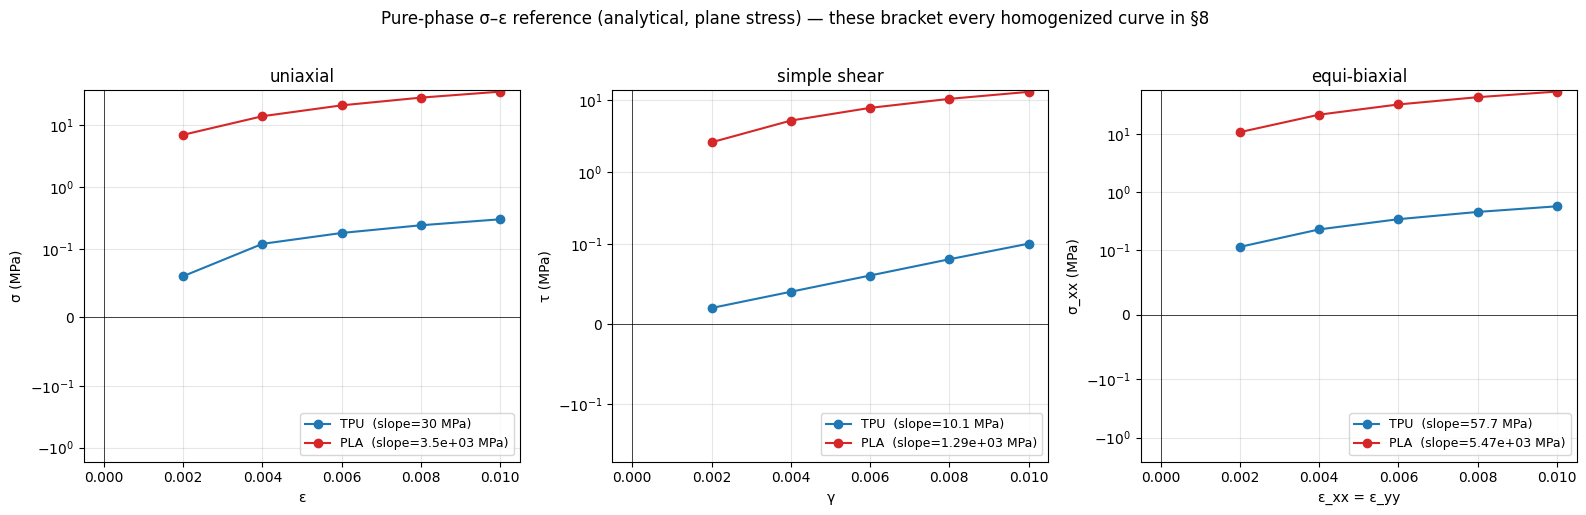

In [2]:
MATERIALS = {
    "TPU": {"E": 30.0,   "nu": 0.48, "rho": 1.2e-9},
    "PLA": {"E": 3500.0, "nu": 0.36, "rho": 1.24e-9},
}
DISP_MAG = 0.01   # matches every entry in load_cases below (§2)
T_RAMP   = 5      # matches campaign["steps"]


def pure_phase_curve(E, nu, mode, disp_mag=DISP_MAG, T=T_RAMP):
    """Analytical plane-stress σ–ε for a single isotropic phase under
    the same quasi-static ramp the FEM solver applies (α = (t+1)/T)."""
    alpha = (np.arange(T) + 1) / T
    if mode == "uniaxial":
        strain = alpha * disp_mag
        stress = E * strain
    elif mode == "shear":
        G = E / (2 * (1 + nu))
        strain = alpha * disp_mag           # γ_xy
        stress = G * strain
    elif mode == "biaxial":
        strain = alpha * disp_mag           # ε_xx = ε_yy
        stress = E / (1 - nu) * strain      # plane-stress equi-biaxial σ_xx
    else:
        raise ValueError(f"unknown mode {mode!r}")
    return strain, stress


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
COLOR = {"TPU": "tab:blue", "PLA": "tab:red"}
for ax, mode, ttl, xl, yl in zip(
    axes,
    ["uniaxial",     "shear",         "biaxial"],
    ["uniaxial",     "simple shear",  "equi-biaxial"],
    ["ε",            "γ",             "ε_xx = ε_yy"],
    ["σ (MPa)",      "τ (MPa)",       "σ_xx (MPa)"],
):
    for name, mp in MATERIALS.items():
        eps, sig = pure_phase_curve(mp["E"], mp["nu"], mode)
        slope = sig[-1] / eps[-1]
        ax.plot(eps, sig, marker="o", color=COLOR[name],
                label=f"{name}  (slope={slope:.3g} MPa)")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
    ax.set_yscale("symlog", linthresh=0.1)   # span 0.1 → 50 MPa cleanly
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9, loc="best")
fig.suptitle("Pure-phase σ–ε reference (analytical, plane stress) — these bracket every homogenized curve in §8", y=1.02)
plt.tight_layout(); plt.show()

## 2. Build a 10 k+ sample YAML programmatically

We sweep three knobs on the GRF microstructure:

* `correlation_length` ∈ {3, 6, 12, 24} — feature size in pixels
* `volume_fraction`    ∈ {0.3, 0.4, 0.5, 0.6} — fraction of soft TPU
* `seed`               ∈ 0..79 — independent realizations

→ 4 × 4 × 80 = **1280 microstructures × 8 load cases = 10 240 samples**.

Per-pair JAX-FEM solve at 64×64 with 5 quasi-static steps takes a few seconds on a laptop; with `mpirun -n 8` the whole sweep is well under an hour.

In [3]:
CORRELATION_LENGTHS = [3.0, 6.0, 12.0, 24.0]
VOLUME_FRACTIONS    = [0.3, 0.4, 0.5, 0.6]
SEEDS               = list(range(80))
GRID_H = GRID_W = 64

geometries = [
    {
        "type": "grf_bimat",
        "h": GRID_H,
        "w": GRID_W,
        "seed": int(seed),
        "correlation_length": float(cl),
        "volume_fraction": float(vf),
        "materials": ["TPU", "PLA"],
    }
    for cl in CORRELATION_LENGTHS
    for vf in VOLUME_FRACTIONS
    for seed in SEEDS
]

load_cases = [
    {"type": "uniaxial", "disp_mag":  0.01, "direction": "x"},
    {"type": "uniaxial", "disp_mag": -0.01, "direction": "x"},
    {"type": "uniaxial", "disp_mag":  0.01, "direction": "y"},
    {"type": "uniaxial", "disp_mag": -0.01, "direction": "y"},
    {"type": "shear",    "disp_mag":  0.01, "direction": "x"},
    {"type": "shear",    "disp_mag":  0.01, "direction": "y"},
    {"type": "biaxial",  "disp_x":  0.01, "disp_y":  0.01},
    {"type": "biaxial",  "disp_x": -0.01, "disp_y": -0.01},
]

campaign = {
    "output_dir": str(OUTPUT_DIR),
    "backend": "jaxfem",
    "steps": 5,
    "materials": MATERIALS,            # sourced from §1 — single source of truth
    "geometries": geometries,
    "load_cases": load_cases,
}

n_geo, n_lc = len(geometries), len(load_cases)
print(f"geometries: {n_geo}  load_cases: {n_lc}  total samples: {n_geo * n_lc}")

geometries: 1280  load_cases: 8  total samples: 10240


In [4]:
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(CONFIG_PATH, "w") as f:
    yaml.safe_dump(campaign, f, sort_keys=False, default_flow_style=None, width=120)

kib = CONFIG_PATH.stat().st_size / 1024
print(f"wrote {CONFIG_PATH.relative_to(REPO)}  ({kib:.1f} KiB)")

config = CampaignConfig.from_file(CONFIG_PATH)
print(f"reload OK: {len(config.geometries)} geo × {len(config.load_cases)} lc = "
      f"{len(config.geometries) * len(config.load_cases)} samples, backend={config.backend}")

wrote configs/bimat_characterization_10k.yaml  (148.6 KiB)
reload OK: 1280 geo × 8 lc = 10240 samples, backend=jaxfem


## 3. Sanity check: dry run + a tiny subset

Two cheap checks before committing to a 10 k-sample sweep:

* **Dry run** — log the planned sample IDs without solving anything.
* **2-sample slice** — pick 2 random pairs (`shuffle=True`, fixed `seed`) and run them inline. If the solver, materials, and BCs are wired up correctly, both samples land under `samples/`.

In [5]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

_ = build_dataset(CONFIG_PATH, limit=4, shuffle=True, seed=7, dry_run=True)

Dry run: 4/10240 pairs would build (limit=4, shuffle=True, seed=7, mpi_size=1)
  g632 × l04 : grf_bimat + shear
  g835 × l07 : grf_bimat + biaxial
  g855 × l00 : grf_bimat + uniaxial
  g1030 × l01 : grf_bimat + uniaxial


In [6]:
# Real run on 2 random pairs.  Reuses the same output_dir as the full sweep —
# sample IDs are stable on (gi, li) so partial runs accumulate cleanly with
# the later mpirun pass.
results = build_dataset(
    CONFIG_PATH,
    limit=2,
    shuffle=True,
    seed=7,
    steps=3,  # smaller for the quick check
)
for p in results:
    print(" ", p.relative_to(REPO))

Sample g632_l04_grf_bimat_64x64_shear: grf_bimat_64x64 + shear


       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[04-27 14:12:37][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.
[04-27 14:12:37][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-27 14:12:37][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[04-27 14:12:37][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[04-27 14:12:37][DEBUG] jax_fem: Done pre-computations, took 0.010616064071655273 [s]
[04-27 14:12:37][INFO] jax_fem: Solving a problem with 4096 cells, 4225x2 = 8450 dofs.
[04-27 14:12:37][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.
[04-27 14:12:37][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-27 14:12:37][DEBUG] jax_fem: Start timing
[04-27 14:12:37][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-27 14:12:38][DEBUG] jax_fem: Function split_and_compute_cell took 0.2993 seconds
[04-27 14:12:38][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-27

  outputs/datasets/bimat_characterization_10k/samples/g632_l04_grf_bimat_64x64_shear.npz
  outputs/datasets/bimat_characterization_10k/samples/g835_l07_grf_bimat_64x64_biaxial.npz


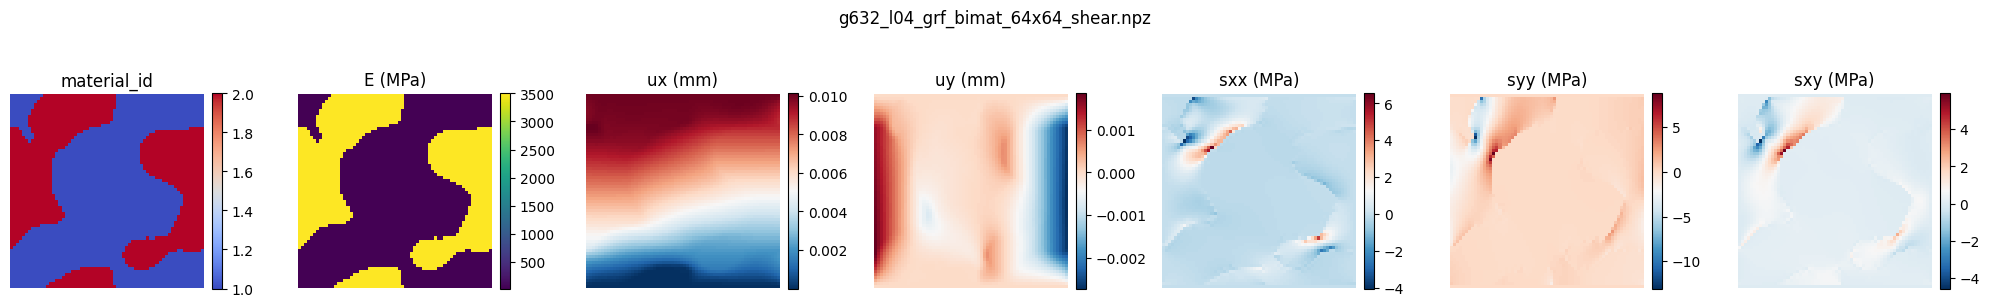

In [7]:
if results:
    arr = np.load(results[0], allow_pickle=True)
    geo, bc, fields = arr["geometry"], arr["boundary"], arr["fields"]
    final = fields[-1]
    titles = ["material_id", "E (MPa)", "ux (mm)", "uy (mm)", "sxx (MPa)", "syy (MPa)", "sxy (MPa)"]
    panels = [geo[1], geo[2], final[0], final[1], final[2], final[3], final[4]]
    fig, axes = plt.subplots(1, len(panels), figsize=(20, 3))
    for ax, t, p in zip(axes, titles, panels):
        cmap = "coolwarm" if t.startswith("material_id") else ("viridis" if "E" in t else "RdBu_r")
        im = ax.imshow(p, origin="lower", cmap=cmap)
        ax.set_title(t); ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(results[0].name, y=1.05)
    plt.tight_layout(); plt.show()

## 4. Launch the full 10 k sweep with MPI

`build_campaign` round-robins `(gi, li)` pairs across MPI ranks (`pairs[rank::size]`) and the JAX-FEM solver pins `petsc4py` to `MPI.COMM_SELF`, so each rank does its own independent solves. Sample IDs are unique per `(gi, li)` so per-rank writes don't collide on the shared `samples/` directory; rank 0 writes the global `index.json` after a barrier.

**Prereqs** (one-time on macOS):

```bash
brew install petsc open-mpi
uv sync --extra jaxfem --extra mpi
export PETSC_DIR=$(brew --prefix petsc) OMPI_CC=/usr/bin/clang
uv pip install 'petsc4py==3.24.*'   # version must match brew petsc; redo after every `uv sync`
```

**Launch the full sweep** (run in your shell from the repo root — `--no-sync` is critical, plain `uv run` would re-wipe `petsc4py`):

```bash
mpirun -n 8 uv run --no-sync fem-sim build-dataset \
    --config configs/bimat_characterization_10k.yaml
```

Pick `-n` to match your physical core count. Each rank logs its own work prefixed `[rN/size]`. To watch progress in another shell while it runs:

```bash
watch -n 5 'ls outputs/datasets/bimat_characterization_10k/samples | wc -l'
```

**Trial a smaller slice first** (4 ranks × 64 samples) before committing to the full 10 240:

```bash
mpirun -n 4 uv run --no-sync fem-sim build-dataset \
    --config configs/bimat_characterization_10k.yaml \
    --limit 64 --shuffle --seed 0
```

Sample IDs are stable on `(gi, li)`, so a slice and the full run write to the same filenames for any overlapping pair — there's no skip-if-exists logic, so re-running the full sweep just overwrites the slice's files. That's fine; the result is identical.

## 5. After the run: inspect `index.json`

Once the `mpirun` job finishes, rank 0 writes `index.json` with the list of successful samples and the MPI size used. The cell below pulls a summary.

In [8]:
index_path = OUTPUT_DIR / "index.json"
if not index_path.exists():
    print(f"(no index yet — run the mpirun command above, then re-run this cell)\n  expected: {index_path}")
else:
    with open(index_path) as f:
        idx = json.load(f)
    print(f"total_samples : {idx['total_samples']}")
    print(f"total_in_grid : {idx['total_in_grid']}")
    print(f"mpi_size      : {idx['mpi_size']}")
    print(f"limit/shuffle : {idx['limit']} / {idx['shuffle']}")
    print(f"first 5 paths :")
    for p in idx["samples"][:5]:
        print(f"  {p}")

total_samples : 2
total_in_grid : 10240
mpi_size      : 1
limit/shuffle : 2 / True
first 5 paths :
  /Users/jt35560/WorkSpace/fem-sim/outputs/datasets/bimat_characterization_10k/samples/g632_l04_grf_bimat_64x64_shear.npz
  /Users/jt35560/WorkSpace/fem-sim/outputs/datasets/bimat_characterization_10k/samples/g835_l07_grf_bimat_64x64_biaxial.npz


## 6. Compare 8 characterization modes for one geometry

Pin `gi=0` (the first microstructure: cl=3, vf=0.3, seed=0) and load all 8 load cases; visualize the final-step `sxx` field. The same pixel-level material pattern responds very differently to each mode — that's the signal the world model should pick up.

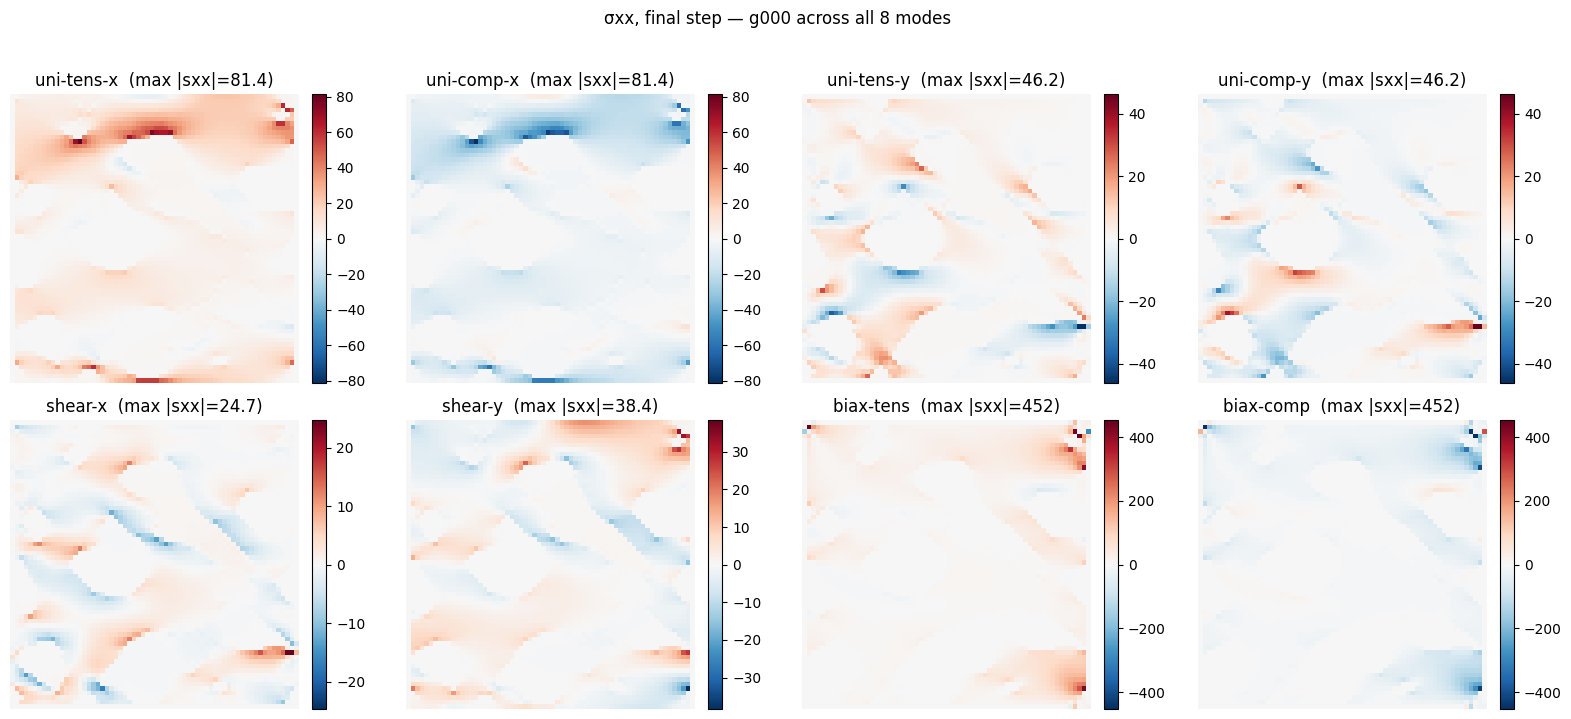

In [9]:
samples_dir = OUTPUT_DIR / "samples"
mode_labels = ["uni-tens-x", "uni-comp-x", "uni-tens-y", "uni-comp-y",
               "shear-x", "shear-y", "biax-tens", "biax-comp"]
GI = 0

paths = sorted(samples_dir.glob(f"g{GI:03d}_l*_grf_bimat_*.npz"))
if len(paths) < 8:
    print(f"only {len(paths)}/8 samples present for gi={GI}; finish the sweep first.")
else:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for ax, p, label in zip(axes.flat, paths, mode_labels):
        arr = np.load(p, allow_pickle=True)
        sxx_final = arr["fields"][-1, 2]
        v = float(np.max(np.abs(sxx_final))) or 1.0
        im = ax.imshow(sxx_final, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
        ax.set_title(f"{label}  (max |sxx|={v:.3g})")
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"σxx, final step — g{GI:03d} across all 8 modes", y=1.02)
    plt.tight_layout(); plt.show()

## 7. Compare microstructures under one mode

Flip the axis: hold the load mode fixed (uniaxial tension x) and walk across microstructures with different correlation lengths. Stress concentration patterns shift from fine speckle (cl=3) to broad domains (cl=24).

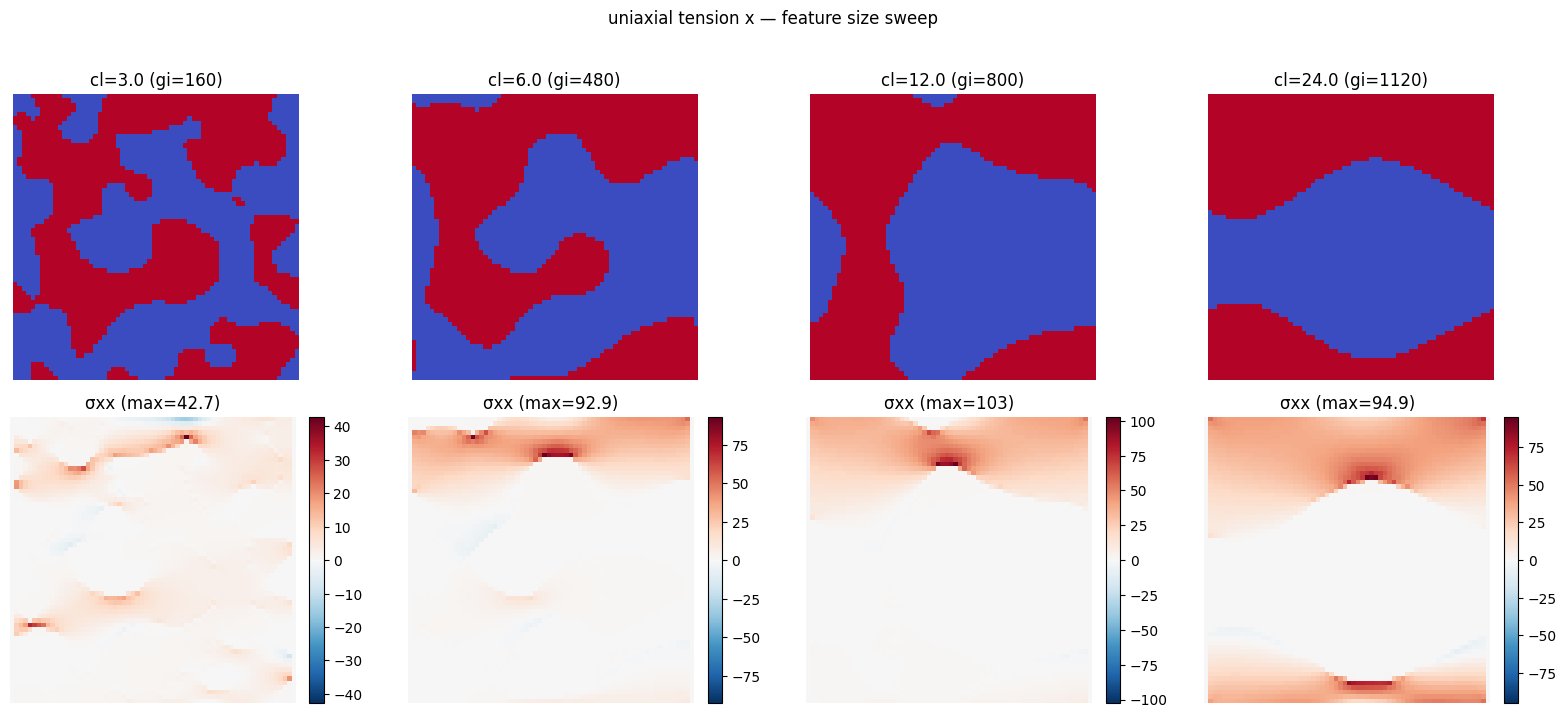

In [10]:
LC = 0  # uniaxial tension x
# pick one geometry per correlation length, fixing vf=0.5, seed=0
TARGET = [(cl, 0.5, 0) for cl in CORRELATION_LENGTHS]

def gi_for(cl, vf, seed):
    for i, g in enumerate(geometries):
        if g["correlation_length"] == cl and g["volume_fraction"] == vf and g["seed"] == seed:
            return i
    return None

fig, axes = plt.subplots(2, len(TARGET), figsize=(4 * len(TARGET), 7))
any_loaded = False
for col, (cl, vf, seed) in enumerate(TARGET):
    gi = gi_for(cl, vf, seed)
    matches = sorted(samples_dir.glob(f"g{gi:03d}_l{LC:02d}_*.npz"))
    if not matches:
        for ax in axes[:, col]:
            ax.text(0.5, 0.5, f"missing\ng{gi:03d} l{LC:02d}", ha="center", va="center")
            ax.axis("off")
        continue
    any_loaded = True
    arr = np.load(matches[0], allow_pickle=True)
    matid = arr["geometry"][1]
    sxx = arr["fields"][-1, 2]
    axes[0, col].imshow(matid, origin="lower", cmap="coolwarm", vmin=1, vmax=2)
    axes[0, col].set_title(f"cl={cl} (gi={gi})"); axes[0, col].axis("off")
    v = float(np.max(np.abs(sxx))) or 1.0
    im = axes[1, col].imshow(sxx, origin="lower", cmap="RdBu_r", vmin=-v, vmax=v)
    axes[1, col].set_title(f"σxx (max={v:.3g})"); axes[1, col].axis("off")
    plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)

if any_loaded:
    fig.suptitle("uniaxial tension x — feature size sweep", y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("no samples on disk yet for this slice — run the mpirun command first.")

## 8. Mechanical property: effective stress–strain curves

Each `.npz` stores the full `(T, 5, H, W)` field history (`[ux, uy, sxx, syy, sxy]`). For each load mode, the *effective* response is the domain-averaged stress versus the prescribed strain:

| mode      | strain                | stress                |
|-----------|-----------------------|-----------------------|
| uniaxial x | ε_xx = u/L_x         | σ̄_xx = ⟨sxx⟩         |
| uniaxial y | ε_yy = u/L_y         | σ̄_yy = ⟨syy⟩         |
| shear x    | γ_xy = u/L_y         | σ̄_xy = ⟨sxy⟩         |
| shear y    | γ_xy = u/L_x         | σ̄_xy = ⟨sxy⟩         |
| biaxial    | ε_xx = u_x/L_x       | σ̄_xx = ⟨sxx⟩         |

Solver convention (`elasticity2d_jaxfem.solve`): `Lx = 1.0`, `Ly = ny/nx`. For our 64×64 grids both are 1.0. The quasi-static ramp gives `α(t) = (t+1)/T` so the prescribed strain at step *t* is `α(t) · u / L`.

The model is linear elasticity, so the σ–ε curves are straight lines whose slopes are the *effective moduli*: `E_eff` (uniaxial), `G_eff` (shear), and the biaxial response. Compare the slopes here to the pure-phase reference in §1 — every effective slope must lie between the TPU and PLA values.

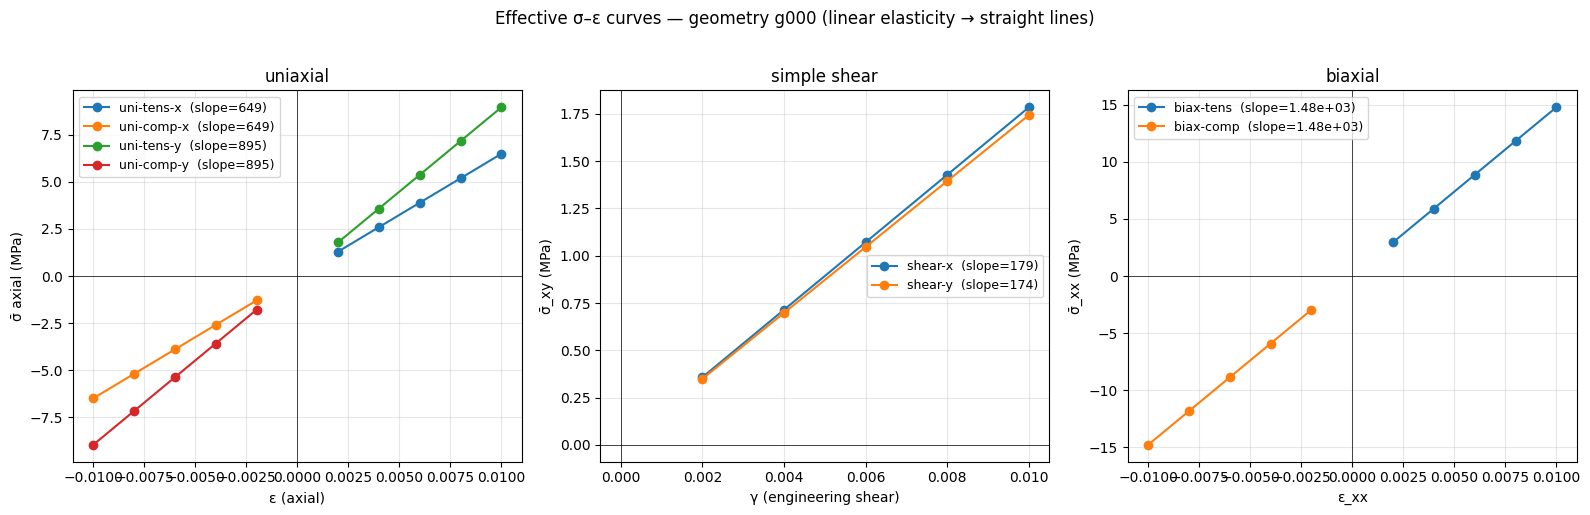

In [11]:
from fem_sim import load_sample

# Stress channels in fields[t, c, y, x]: 0=ux, 1=uy, 2=sxx, 3=syy, 4=sxy
_CH_SXX, _CH_SYY, _CH_SXY = 2, 3, 4

def stress_strain_curve(npz_path):
    """Pull (strain, stress, label, slope) from a sample.

    Returns the effective σ–ε curve appropriate to the sample's load mode,
    plus the linear-fit slope (effective modulus, MPa).
    """
    s = load_sample(npz_path)
    fields = s.fields                           # (T, 5, H, W)
    solid = s.geometry[0] > 0
    spec = s.metadata.get("load_case_spec", {})
    H, W = solid.shape
    Lx, Ly = 1.0, H / W                         # solver convention
    T = fields.shape[0]
    alpha = (np.arange(T) + 1) / T              # quasi-static ramp

    mode = spec.get("type")
    direction = spec.get("direction", "x")

    if mode == "uniaxial" and direction == "x":
        d = spec["disp_mag"]
        strain = alpha * d / Lx
        stress = fields[:, _CH_SXX][:, solid].mean(axis=1)
        label = f"uni-{'tens' if d > 0 else 'comp'}-x"
    elif mode == "uniaxial" and direction == "y":
        d = spec["disp_mag"]
        strain = alpha * d / Ly
        stress = fields[:, _CH_SYY][:, solid].mean(axis=1)
        label = f"uni-{'tens' if d > 0 else 'comp'}-y"
    elif mode == "shear" and direction == "x":
        d = spec["disp_mag"]
        strain = alpha * d / Ly                  # γ_xy
        stress = fields[:, _CH_SXY][:, solid].mean(axis=1)
        label = "shear-x"
    elif mode == "shear" and direction == "y":
        d = spec["disp_mag"]
        strain = alpha * d / Lx                  # γ_xy
        stress = fields[:, _CH_SXY][:, solid].mean(axis=1)
        label = "shear-y"
    elif mode == "biaxial":
        dx = spec["disp_x"]
        strain = alpha * dx / Lx
        stress = fields[:, _CH_SXX][:, solid].mean(axis=1)
        label = f"biax-{'tens' if dx > 0 else 'comp'}"
    else:
        raise ValueError(f"unsupported mode {mode!r}")

    # Linear fit through origin: σ = E · ε
    if np.any(strain != 0):
        slope = float(np.dot(strain, stress) / np.dot(strain, strain))
    else:
        slope = float("nan")
    return strain, stress, label, slope


GI = 0
samples_dir = OUTPUT_DIR / "samples"
paths = sorted(samples_dir.glob(f"g{GI:03d}_l*_grf_bimat_*.npz"))

if not paths:
    print(f"no samples on disk yet for gi={GI} — run §2 (mini run) or §3 (full mpirun) first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for p in paths:
        strain, stress, label, slope = stress_strain_curve(p)
        if label.startswith("uni"):
            ax = axes[0]
        elif label.startswith("shear"):
            ax = axes[1]
        else:
            ax = axes[2]
        ax.plot(strain, stress, marker="o", label=f"{label}  (slope={slope:.3g})")
    for ax, ttl, xl, yl in zip(
        axes,
        ["uniaxial",                   "simple shear",          "biaxial"],
        ["ε (axial)",                  "γ (engineering shear)", "ε_xx"],
        ["σ̄ axial (MPa)",              "σ̄_xy (MPa)",            "σ̄_xx (MPa)"],
    ):
        ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="best")
    fig.suptitle(f"Effective σ–ε curves — geometry g{GI:03d} (linear elasticity → straight lines)", y=1.02)
    plt.tight_layout(); plt.show()

## 9. Property sweep across the dataset — `E_eff(cl, vf)`

With effective moduli computable per sample, the campaign becomes a *homogenization* dataset: for each microstructure, fit `E_eff = σ̄_xx / ε_xx` from the uniaxial-tension-x mode (li=0), then group by `(correlation_length, volume_fraction)` and average over seeds.

The cell below walks every available `*_l00_*.npz` on disk, extracts `E_eff_x`, joins it back to the geometry spec via `geometry_index`, and renders a heatmap with per-cell sample counts so you can see how thoroughly the sweep has filled in. It runs cleanly even with a partial dataset — useful while a long `mpirun` is still going.

loaded 1000 samples covering 13 (cl, vf) cells


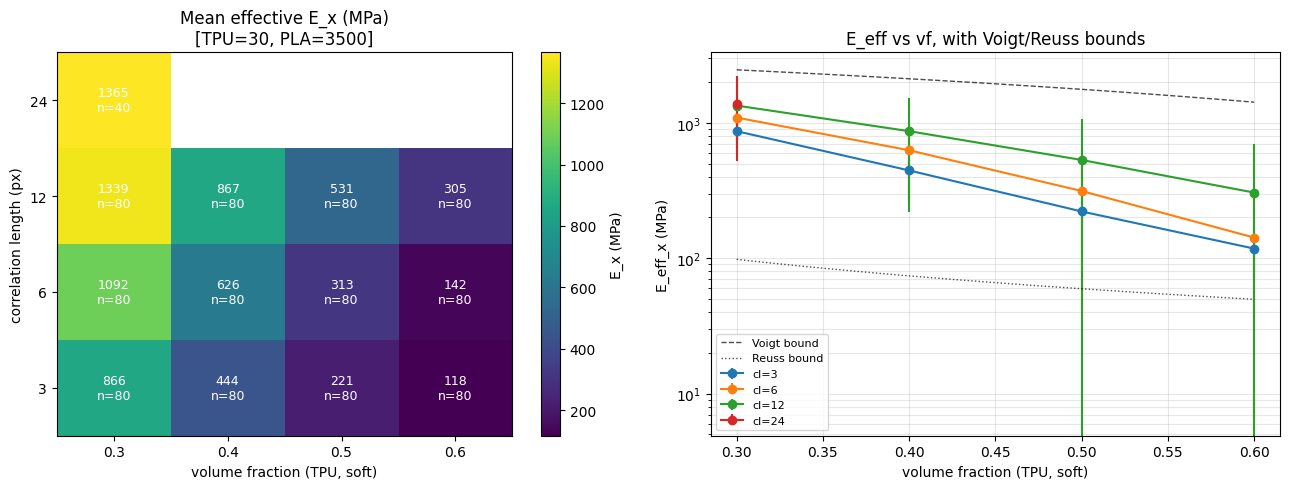

In [12]:
import re
from collections import defaultdict

_GI_RE = re.compile(r"^g(\d{3})_l00_")

records = []
for p in sorted(samples_dir.glob("g*_l00_*.npz")):
    m = _GI_RE.match(p.name)
    if not m:
        continue
    gi = int(m.group(1))
    if gi >= len(geometries):
        continue
    g = geometries[gi]
    try:
        _, _, _, slope = stress_strain_curve(p)
    except (ValueError, KeyError):
        continue
    records.append({
        "gi": gi,
        "cl": g["correlation_length"],
        "vf": g["volume_fraction"],
        "seed": g["seed"],
        "E_eff": slope,
    })

if not records:
    print("no uniaxial-tension-x samples on disk yet — kick off the sweep first.")
else:
    print(f"loaded {len(records)} samples covering "
          f"{len({(r['cl'], r['vf']) for r in records})} (cl, vf) cells")

    cls_present = sorted({r["cl"] for r in records})
    vfs_present = sorted({r["vf"] for r in records})

    grid = defaultdict(list)
    for r in records:
        grid[(r["cl"], r["vf"])].append(r["E_eff"])

    Z = np.full((len(cls_present), len(vfs_present)), np.nan)
    Zstd = np.zeros_like(Z)
    N = np.zeros_like(Z, dtype=int)
    for i, cl in enumerate(cls_present):
        for j, vf in enumerate(vfs_present):
            vals = grid.get((cl, vf), [])
            if vals:
                Z[i, j] = np.mean(vals)
                Zstd[i, j] = np.std(vals)
                N[i, j] = len(vals)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    im0 = axes[0].imshow(Z, origin="lower", cmap="viridis", aspect="auto")
    axes[0].set_xticks(range(len(vfs_present))); axes[0].set_xticklabels([f"{v:.1f}" for v in vfs_present])
    axes[0].set_yticks(range(len(cls_present))); axes[0].set_yticklabels([f"{c:.0f}" for c in cls_present])
    axes[0].set_xlabel("volume fraction (TPU, soft)")
    axes[0].set_ylabel("correlation length (px)")
    axes[0].set_title(f"Mean effective E_x (MPa)\n[TPU=30, PLA=3500]")
    for i in range(len(cls_present)):
        for j in range(len(vfs_present)):
            if not np.isnan(Z[i, j]):
                axes[0].text(j, i, f"{Z[i,j]:.0f}\nn={N[i,j]}",
                             ha="center", va="center",
                             color="white", fontsize=9)
    plt.colorbar(im0, ax=axes[0], label="E_x (MPa)")

    # Trend: E_eff vs volume fraction at each correlation length
    for i, cl in enumerate(cls_present):
        ys = Z[i, :]
        es = Zstd[i, :]
        valid = ~np.isnan(ys)
        if valid.any():
            axes[1].errorbar(np.array(vfs_present)[valid], ys[valid], yerr=es[valid],
                             marker="o", label=f"cl={cl:.0f}")
    # Voigt (parallel) and Reuss (series) bounds for E (Hill bounds, isotropic mix)
    E_TPU, E_PLA = 30.0, 3500.0
    vf_grid = np.linspace(min(vfs_present), max(vfs_present), 50)
    voigt = vf_grid * E_TPU + (1 - vf_grid) * E_PLA
    reuss = 1.0 / (vf_grid / E_TPU + (1 - vf_grid) / E_PLA)
    axes[1].plot(vf_grid, voigt, "k--", lw=1, alpha=0.7, label="Voigt bound")
    axes[1].plot(vf_grid, reuss, "k:",  lw=1, alpha=0.7, label="Reuss bound")
    axes[1].set_xlabel("volume fraction (TPU, soft)")
    axes[1].set_ylabel("E_eff_x (MPa)")
    axes[1].set_yscale("log")
    axes[1].set_title("E_eff vs vf, with Voigt/Reuss bounds")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, which="both")

    plt.tight_layout(); plt.show()

## 10. Optional: export to ParaView

For movie-style inspection of one sample (or small subset), write a `.pvd` collection that ParaView opens as an animation:

```bash
uv run fem-sim export-vtk outputs/datasets/bimat_characterization_10k/samples/g000_l00_*.npz
```

Or export inline with the sweep by adding `--export-vtk` to the `mpirun` command (writes `.pvd` per sample under `vtk/<sample_id>/`). Skip this for the full 10 k run unless you really want 10 k movies on disk — better to export a curated subset after the fact.